# 07c — EGFR MD Hotspot and Interface Validation

## Pipeline 3 — Molecular Dynamics and Binding-Energy Analysis

This notebook integrates the **dynamic interface information** obtained in:

```text
07b_EGFR_Dimer_MD_Contact_Persistence.ipynb
```

with the **static / energetic interface information** generated in the earlier PEARL pipelines.

The goal is not to run another simulation.

The goal is to answer:

> Which residues and contacts are supported simultaneously by static structure, FoldX hotspot analysis and molecular-dynamics persistence?

---

## Conceptual workflow

```text
static B–D interface
        +
FoldX energetic hotspots
        +
1 ns MD contact persistence
        ↓
dynamic interface validation
        ↓
persistent hotspot residues
        ↓
relationship to F0010
```

The reference short peptide is:

```text
F0010
IGERCQYRDLK
```

corresponding to chain D residues 38–48 in the current PEARL mapping.

---

## Important interpretation

A residue supported by several computational methods can be prioritised more strongly.

However:

```text
FoldX + MD + docking
```

is still **computational convergence**, not experimental validation.


## 1. Imports

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("Imports OK")


Imports OK


## 2. Configuration

In [2]:
# ------------------------------------------------------
# 07b outputs
# ------------------------------------------------------
RUN_LABEL = "production_1ns"

INPUT_07B = (
    Path("outputs")
    / "pipeline_3_md_07b_contact_persistence"
    / RUN_LABEL
)

ANALYSIS_07B = INPUT_07B / "analysis"

CONTACTS_CSV = (
    ANALYSIS_07B
    / "BD_contact_persistence.csv"
)

PERSISTENT_CONTACTS_CSV = (
    ANALYSIS_07B
    / "BD_persistent_contacts_50pct.csv"
)

B_RESIDUE_CSV = (
    ANALYSIS_07B
    / "chain_B_residue_contact_persistence.csv"
)

D_RESIDUE_CSV = (
    ANALYSIS_07B
    / "chain_D_residue_contact_persistence.csv"
)

RMSF_CSV = (
    ANALYSIS_07B
    / "rmsf_ca_by_residue.csv"
)

SUMMARY_07B_CSV = (
    ANALYSIS_07B
    / "07b_summary_metrics.csv"
)

# ------------------------------------------------------
# Pipeline 1/2 energetic hotspot files
# ------------------------------------------------------
# The notebook searches several common PEARL output paths automatically.
HOTSPOT_CANDIDATES = [
    Path("outputs/energetic_hotspots.csv"),
    Path("outputs/interface_residues_with_foldx_ddg.csv"),
    Path("outputs/energetic_contiguous_windows_ranked.csv"),
    Path("outputs/pipeline_1_initial_prototype/energetic_hotspots.csv"),
    Path("outputs/pipeline_2_structural_validation_and_docking/energetic_hotspots.csv"),
]

# ------------------------------------------------------
# Biological definitions
# ------------------------------------------------------
CHAIN_B = "B"
CHAIN_D = "D"

F0010_SEQUENCE = "IGERCQYRDLK"
F0010_START_RESID = 38
F0010_END_RESID = 48

PERSISTENCE_THRESHOLD = 0.50
HIGH_PERSISTENCE_THRESHOLD = 0.80

# FoldX hotspot threshold used in previous PEARL stages
FOLDX_HOTSPOT_THRESHOLD = 1.5

# ------------------------------------------------------
# Output
# ------------------------------------------------------
OUTPUT_DIR = (
    Path("outputs")
    / "pipeline_3_md_07c_hotspot_interface_validation"
)

TABLE_DIR = OUTPUT_DIR / "tables"
REPORT_DIR = OUTPUT_DIR / "reports"

for d in [OUTPUT_DIR, TABLE_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("07b input:", INPUT_07B.resolve())
print("Output:", OUTPUT_DIR.resolve())


07b input: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_3_md_07b_contact_persistence/production_1ns
Output: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_3_md_07c_hotspot_interface_validation


## 3. Check required 07b files

In [14]:
required_files = [
    CONTACTS_CSV,
    PERSISTENT_CONTACTS_CSV,
    B_RESIDUE_CSV,
    D_RESIDUE_CSV,
    RMSF_CSV,
    SUMMARY_07B_CSV,
]

checks = pd.DataFrame([
    {
        "file": str(path),
        "exists": path.exists(),
        "size_kB": path.stat().st_size / 1024 if path.exists() else np.nan,
    }
    for path in required_files
])

display(checks)

if not checks["exists"].all():
    missing = checks.loc[~checks["exists"], "file"].tolist()
    raise FileNotFoundError(
        "Missing required 07b files:\n" + "\n".join(missing)
    )

print("07b input check: PASS")


,file,exists,size_kB
0,outputs/pipeline_3_md_07b_contact_persistence/...,True,8.607422
1,outputs/pipeline_3_md_07b_contact_persistence/...,True,4.413086
2,outputs/pipeline_3_md_07b_contact_persistence/...,True,1.094727
3,outputs/pipeline_3_md_07b_contact_persistence/...,True,0.865234
4,outputs/pipeline_3_md_07b_contact_persistence/...,True,18.461914
5,outputs/pipeline_3_md_07b_contact_persistence/...,True,0.639648


07b input check: PASS


## 4. Load MD contact-persistence results

In [15]:
contact_df = pd.read_csv(CONTACTS_CSV)
persistent_contact_df = pd.read_csv(PERSISTENT_CONTACTS_CSV)
B_residue_df = pd.read_csv(B_RESIDUE_CSV)
D_residue_df = pd.read_csv(D_RESIDUE_CSV)
rmsf_df = pd.read_csv(RMSF_CSV)
summary_07b_df = pd.read_csv(SUMMARY_07B_CSV)

print("All contacts:", len(contact_df))
print("Persistent contacts >=50%:", len(persistent_contact_df))
print("B dynamic residues:", len(B_residue_df))
print("D dynamic residues:", len(D_residue_df))

display(contact_df.head(10))


All contacts: 147
Persistent contacts >=50%: 74
B dynamic residues: 45
D dynamic residues: 35


,B_resname,B_resid,D_resname,D_resid,frames_in_contact,n_frames,persistence,persistence_percent,mean_min_distance_A,persistent_50pct
0,ASP,355,ARG,41,500,500,1.0,100.0,2.766057,True
1,GLN,411,LYS,48,500,500,1.0,100.0,2.893933,True
2,GLN,16,CYS,31,500,500,1.0,100.0,2.920914,True
3,GLN,16,CYS,33,500,500,1.0,100.0,2.933336,True
4,GLN,16,ASN,32,500,500,1.0,100.0,3.040986,True
5,ARG,29,TRP,49,500,500,1.0,100.0,3.217261,True
6,GLN,384,ARG,45,500,500,1.0,100.0,3.360474,True
7,THR,15,GLY,39,500,500,1.0,100.0,3.381690,True
8,THR,15,CYS,31,500,500,1.0,100.0,3.398697,True
9,PHE,412,LEU,47,500,500,1.0,100.0,3.431400,True


## 5. Identify the hotspot table automatically

In [16]:
existing_hotspot_files = [
    path
    for path in HOTSPOT_CANDIDATES
    if path.exists()
]

print("Candidate hotspot files found:")
for path in existing_hotspot_files:
    print(" ", path)

HOTSPOT_FILE = (
    existing_hotspot_files[0]
    if existing_hotspot_files
    else None
)

if HOTSPOT_FILE is None:
    print(
        "\nNo hotspot CSV was found automatically.\n"
        "The MD-only sections of the notebook will still run.\n"
        "Set HOTSPOT_FILE manually to the FoldX hotspot CSV before "
        "running the integration sections."
    )
else:
    print("\nUsing hotspot file:", HOTSPOT_FILE)


Candidate hotspot files found:
  outputs/energetic_hotspots.csv
  outputs/interface_residues_with_foldx_ddg.csv
  outputs/energetic_contiguous_windows_ranked.csv

Using hotspot file: outputs/energetic_hotspots.csv


## 6. Flexible hotspot-table parser

Earlier PEARL notebooks may use slightly different column names.

This parser attempts to identify:

- chain;
- residue number;
- residue name;
- FoldX ΔΔG;
- hotspot flag.

If the automatic parser cannot identify the required fields, it will show the available columns instead of guessing.


In [17]:
hotspot_df = None
hotspot_columns_detected = {}

def find_column(columns, candidates):
    lower_map = {
        str(c).lower(): c
        for c in columns
    }

    for candidate in candidates:
        for lower_name, original in lower_map.items():
            if candidate.lower() == lower_name:
                return original

    for candidate in candidates:
        for lower_name, original in lower_map.items():
            if candidate.lower() in lower_name:
                return original

    return None

if HOTSPOT_FILE is not None:
    raw_hotspot_df = pd.read_csv(HOTSPOT_FILE)

    print("Hotspot columns:")
    print(list(raw_hotspot_df.columns))

    chain_col = find_column(
        raw_hotspot_df.columns,
        ["chain", "chain_id"]
    )

    resid_col = find_column(
        raw_hotspot_df.columns,
        [
            "resseq",
            "resid",
            "residue_number",
            "residue_id",
        ]
    )

    resname_col = find_column(
        raw_hotspot_df.columns,
        [
            "resname",
            "residue_name",
            "aa",
        ]
    )

    ddg_col = find_column(
        raw_hotspot_df.columns,
        [
            "ddg",
            "ddg_kcal_mol",
            "foldx_ddg",
            "alanine_scan_ddg_kcal_mol",
        ]
    )

    hotspot_flag_col = find_column(
        raw_hotspot_df.columns,
        [
            "is_hotspot",
            "hotspot",
            "energetic_hotspot",
        ]
    )

    hotspot_columns_detected = {
        "chain": chain_col,
        "resid": resid_col,
        "resname": resname_col,
        "ddg": ddg_col,
        "hotspot_flag": hotspot_flag_col,
    }

    print("\nDetected:")
    display(pd.DataFrame(
        list(hotspot_columns_detected.items()),
        columns=["role", "column"]
    ))

    if chain_col is not None and resid_col is not None:
        hotspot_df = pd.DataFrame({
            "chain": raw_hotspot_df[chain_col].astype(str),
            "resid": pd.to_numeric(
                raw_hotspot_df[resid_col],
                errors="coerce",
            ),
        })

        if resname_col is not None:
            hotspot_df["resname"] = (
                raw_hotspot_df[resname_col]
                .astype(str)
            )
        else:
            hotspot_df["resname"] = None

        if ddg_col is not None:
            hotspot_df["foldx_ddG_kcal_mol"] = pd.to_numeric(
                raw_hotspot_df[ddg_col],
                errors="coerce",
            )
        else:
            hotspot_df["foldx_ddG_kcal_mol"] = np.nan

        if hotspot_flag_col is not None:
            hotspot_df["is_foldx_hotspot"] = (
                raw_hotspot_df[hotspot_flag_col]
                .astype(bool)
            )
        elif ddg_col is not None:
            hotspot_df["is_foldx_hotspot"] = (
                hotspot_df["foldx_ddG_kcal_mol"]
                > FOLDX_HOTSPOT_THRESHOLD
            )
        else:
            hotspot_df["is_foldx_hotspot"] = False

        hotspot_df = hotspot_df.dropna(subset=["resid"]).copy()
        hotspot_df["resid"] = hotspot_df["resid"].astype(int)

        hotspot_df = (
            hotspot_df
            .drop_duplicates(
                subset=["chain", "resid"]
            )
            .reset_index(drop=True)
        )

        print("\nNormalized hotspot table:")
        display(hotspot_df.head(20))
    else:
        print(
            "\nCould not identify chain/residue columns automatically."
        )


Hotspot columns:
['chain', 'resseq', 'resname', 'node', 'aa1', 'n_contacts', 'degree', 'betweenness', 'graph_proxy_score', 'foldx_buildmodel_mutation', 'scan_required', 'ddG_kcal_mol', 'source_file', 'raw_line', 'has_foldx_ddg', 'is_energetic_hotspot', 'is_graph_proxy_hotspot_like']

Detected:


,role,column
0,chain,chain
1,resid,resseq
2,resname,resname
3,ddg,ddG_kcal_mol
4,hotspot_flag,is_energetic_hotspot



Normalized hotspot table:


,chain,resid,resname,foldx_ddG_kcal_mol,is_foldx_hotspot
0,D,45,ARG,2.00281,True
1,D,33,CYS,2.91303,True
2,D,43,GLN,2.51557,True
3,D,26,LEU,4.15852,True
4,D,23,ILE,3.65614,True
5,D,41,ARG,5.73455,True
6,D,39,GLY,5.87659,True
7,D,16,HIS,2.44148,True
8,D,47,LEU,3.54371,True
9,D,44,TYR,3.37068,True


## 7. Dynamic residue support from MD

In [18]:
def prepare_dynamic_residue_table(
    residue_df,
    chain_id,
    resid_col,
    resname_col,
):
    out = residue_df.copy()

    out = out.rename(columns={
        resid_col: "resid",
        resname_col: "resname",
    })

    out["chain"] = chain_id

    out["dynamic_contact_support"] = pd.cut(
        out["max_contact_persistence"],
        bins=[-np.inf, 0.25, 0.50, 0.80, np.inf],
        labels=[
            "low",
            "moderate",
            "persistent",
            "very_persistent",
        ],
    )

    return out

B_dynamic = prepare_dynamic_residue_table(
    B_residue_df,
    CHAIN_B,
    "B_resid",
    "B_resname",
)

D_dynamic = prepare_dynamic_residue_table(
    D_residue_df,
    CHAIN_D,
    "D_resid",
    "D_resname",
)

dynamic_residue_df = pd.concat(
    [B_dynamic, D_dynamic],
    ignore_index=True,
)

dynamic_residue_df.to_csv(
    TABLE_DIR / "dynamic_interface_residue_support.csv",
    index=False,
)

print("Top dynamic residues:")
display(
    dynamic_residue_df
    .sort_values(
        "max_contact_persistence",
        ascending=False,
    )
    .head(30)
)


Top dynamic residues:


,resid,resname,max_contact_persistence,mean_contact_persistence,n_partner_residues,chain,dynamic_contact_support
0,409,HIS,1.0,0.771429,7,B,very_persistent
56,26,LEU,1.0,0.597143,7,D,very_persistent
65,12,GLY,1.0,0.733333,3,D,very_persistent
64,13,TYR,1.0,0.530000,2,D,very_persistent
63,15,LEU,1.0,0.685000,4,D,very_persistent
62,16,HIS,1.0,0.980000,3,D,very_persistent
61,21,MET,1.0,0.573333,3,D,very_persistent
60,23,ILE,1.0,0.680000,4,D,very_persistent
59,49,TRP,1.0,0.655000,4,D,very_persistent
58,25,ALA,1.0,0.825000,4,D,very_persistent


## 8. Add RMSF to dynamic residue support

In [19]:
rmsf_norm = rmsf_df.copy()

rmsf_norm = rmsf_norm.rename(columns={
    "chain": "chain",
    "resid": "resid",
    "resname": "rmsf_resname",
    "rmsf_A": "CA_RMSF_A",
})

dynamic_with_rmsf_df = dynamic_residue_df.merge(
    rmsf_norm[
        [
            "chain",
            "resid",
            "CA_RMSF_A",
        ]
    ],
    on=["chain", "resid"],
    how="left",
)

dynamic_with_rmsf_df.to_csv(
    TABLE_DIR / "dynamic_interface_with_rmsf.csv",
    index=False,
)

display(
    dynamic_with_rmsf_df
    .sort_values(
        [
            "max_contact_persistence",
            "CA_RMSF_A",
        ],
        ascending=[False, True],
    )
    .head(30)
)


,resid,resname,max_contact_persistence,mean_contact_persistence,n_partner_residues,chain,dynamic_contact_support,CA_RMSF_A
14,408,GLN,1.0,0.693333,3,B,very_persistent,0.555332
8,412,PHE,1.0,1.000000,2,B,very_persistent,0.573009
6,98,LEU,1.0,1.000000,1,B,very_persistent,0.582019
10,415,ALA,1.0,1.000000,1,B,very_persistent,0.582791
0,409,HIS,1.0,0.771429,7,B,very_persistent,0.611444
3,411,GLN,1.0,1.000000,1,B,very_persistent,0.620282
53,31,CYS,1.0,0.766667,3,D,very_persistent,0.631991
15,438,ILE,1.0,1.000000,1,B,very_persistent,0.636988
5,99,SER,1.0,1.000000,2,B,very_persistent,0.637716
55,47,LEU,1.0,0.695556,9,D,very_persistent,0.674007


## 9. Integrate MD with FoldX hotspots

If a valid hotspot table was found, this section merges energetic and dynamic evidence.

The resulting table distinguishes:

```text
FoldX hotspot only
MD-persistent only
FoldX hotspot + MD persistent
neither
```


In [20]:
integrated_df = None

if hotspot_df is not None:
    integrated_df = dynamic_with_rmsf_df.merge(
        hotspot_df[
            [
                "chain",
                "resid",
                "foldx_ddG_kcal_mol",
                "is_foldx_hotspot",
            ]
        ],
        on=["chain", "resid"],
        how="outer",
    )

    integrated_df["max_contact_persistence"] = (
        integrated_df["max_contact_persistence"]
        .fillna(0.0)
    )

    integrated_df["is_md_persistent"] = (
        integrated_df["max_contact_persistence"]
        >= PERSISTENCE_THRESHOLD
    )

    integrated_df["is_md_very_persistent"] = (
        integrated_df["max_contact_persistence"]
        >= HIGH_PERSISTENCE_THRESHOLD
    )

    integrated_df["is_foldx_hotspot"] = (
        integrated_df["is_foldx_hotspot"]
        .fillna(False)
        .astype(bool)
    )

    def evidence_class(row):
        foldx = bool(row["is_foldx_hotspot"])
        mdp = bool(row["is_md_persistent"])

        if foldx and mdp:
            return "FoldX_hotspot_and_MD_persistent"
        if foldx:
            return "FoldX_hotspot_only"
        if mdp:
            return "MD_persistent_only"
        return "neither"

    integrated_df["evidence_class"] = (
        integrated_df.apply(
            evidence_class,
            axis=1,
        )
    )

    integrated_df.to_csv(
        TABLE_DIR
        / "FoldX_MD_integrated_residue_validation.csv",
        index=False,
    )

    print("Evidence classes:")
    display(
        integrated_df["evidence_class"]
        .value_counts()
        .rename_axis("class")
        .reset_index(name="count")
    )

    print(
        "\nResidues supported by both FoldX and MD:"
    )

    display(
        integrated_df[
            integrated_df["evidence_class"]
            == "FoldX_hotspot_and_MD_persistent"
        ]
        .sort_values(
            [
                "max_contact_persistence",
                "foldx_ddG_kcal_mol",
            ],
            ascending=[False, False],
        )
    )
else:
    print(
        "FoldX integration skipped because no hotspot table was loaded."
    )


Evidence classes:


,class,count
0,MD_persistent_only,48
1,neither,17
2,FoldX_hotspot_and_MD_persistent,15



Residues supported by both FoldX and MD:


,resid,resname,max_contact_persistence,mean_contact_persistence,n_partner_residues,chain,dynamic_contact_support,CA_RMSF_A,foldx_ddG_kcal_mol,is_foldx_hotspot,is_md_persistent,is_md_very_persistent,evidence_class
67,39,GLY,1.00,0.800000,4,D,very_persistent,0.765753,5.87659,True,True,True,FoldX_hotspot_and_MD_persistent
69,41,ARG,1.00,0.840000,5,D,very_persistent,0.721614,5.73455,True,True,True,FoldX_hotspot_and_MD_persistent
56,26,LEU,1.00,0.597143,7,D,very_persistent,0.932635,4.15852,True,True,True,FoldX_hotspot_and_MD_persistent
53,23,ILE,1.00,0.680000,4,D,very_persistent,0.845328,3.65614,True,True,True,FoldX_hotspot_and_MD_persistent
75,47,LEU,1.00,0.695556,9,D,very_persistent,0.674007,3.54371,True,True,True,FoldX_hotspot_and_MD_persistent
72,44,TYR,1.00,0.705714,7,D,very_persistent,0.805082,3.37068,True,True,True,FoldX_hotspot_and_MD_persistent
49,13,TYR,1.00,0.530000,2,D,very_persistent,0.972796,3.32989,True,True,True,FoldX_hotspot_and_MD_persistent
62,33,CYS,1.00,0.610000,4,D,very_persistent,0.754004,2.91303,True,True,True,FoldX_hotspot_and_MD_persistent
48,12,GLY,1.00,0.733333,3,D,very_persistent,1.212198,2.88259,True,True,True,FoldX_hotspot_and_MD_persistent
71,43,GLN,1.00,0.745000,4,D,very_persistent,0.714160,2.51557,True,True,True,FoldX_hotspot_and_MD_persistent


## 10. F0010 residue map

In [21]:
if (
    len(F0010_SEQUENCE)
    != F0010_END_RESID
    - F0010_START_RESID
    + 1
):
    raise ValueError(
        "F0010 sequence length does not match the configured residue interval."
    )

f0010_rows = []

for offset, aa in enumerate(F0010_SEQUENCE):
    resid = F0010_START_RESID + offset

    f0010_rows.append({
        "sequence_position_1based": offset + 1,
        "chain": CHAIN_D,
        "resid": resid,
        "aa": aa,
    })

f0010_df = pd.DataFrame(f0010_rows)

display(f0010_df)


,sequence_position_1based,chain,resid,aa
0,1,D,38,I
1,2,D,39,G
2,3,D,40,E
3,4,D,41,R
4,5,D,42,C
5,6,D,43,Q
6,7,D,44,Y
7,8,D,45,R
8,9,D,46,D
9,10,D,47,L


## 11. Dynamic support for F0010

In [22]:
f0010_dynamic_df = f0010_df.merge(
    D_dynamic[
        [
            "chain",
            "resid",
            "resname",
            "max_contact_persistence",
            "mean_contact_persistence",
            "n_partner_residues",
            "dynamic_contact_support",
        ]
    ],
    on=["chain", "resid"],
    how="left",
)

f0010_dynamic_df = f0010_dynamic_df.merge(
    rmsf_norm[
        [
            "chain",
            "resid",
            "CA_RMSF_A",
        ]
    ],
    on=["chain", "resid"],
    how="left",
)

f0010_dynamic_df["max_contact_persistence"] = (
    f0010_dynamic_df["max_contact_persistence"]
    .fillna(0.0)
)

f0010_dynamic_df["is_md_persistent"] = (
    f0010_dynamic_df["max_contact_persistence"]
    >= PERSISTENCE_THRESHOLD
)

if hotspot_df is not None:
    f0010_dynamic_df = f0010_dynamic_df.merge(
        hotspot_df[
            [
                "chain",
                "resid",
                "foldx_ddG_kcal_mol",
                "is_foldx_hotspot",
            ]
        ],
        on=["chain", "resid"],
        how="left",
    )

    f0010_dynamic_df["is_foldx_hotspot"] = (
        f0010_dynamic_df["is_foldx_hotspot"]
        .fillna(False)
    )

f0010_dynamic_df.to_csv(
    TABLE_DIR / "F0010_MD_dynamic_support.csv",
    index=False,
)

display(f0010_dynamic_df)


,sequence_position_1based,chain,resid,aa,resname,max_contact_persistence,mean_contact_persistence,n_partner_residues,dynamic_contact_support,CA_RMSF_A,is_md_persistent,foldx_ddG_kcal_mol,is_foldx_hotspot
0,1,D,38,I,ILE,1.0,0.766667,3,very_persistent,0.752609,True,NaN,False
1,2,D,39,G,GLY,1.0,0.800000,4,very_persistent,0.765753,True,5.87659,True
2,3,D,40,E,GLU,1.0,0.995000,4,very_persistent,0.761310,True,NaN,False
3,4,D,41,R,ARG,1.0,0.840000,5,very_persistent,0.721614,True,5.73455,True
4,5,D,42,C,CYS,0.7,0.700000,1,persistent,0.667259,True,NaN,False
5,6,D,43,Q,GLN,1.0,0.745000,4,very_persistent,0.714160,True,2.51557,True
6,7,D,44,Y,TYR,1.0,0.705714,7,very_persistent,0.805082,True,3.37068,True
7,8,D,45,R,ARG,1.0,0.376667,6,very_persistent,0.829169,True,2.00281,True
8,9,D,46,D,ASP,1.0,1.000000,1,very_persistent,0.704795,True,NaN,False
9,10,D,47,L,LEU,1.0,0.695556,9,very_persistent,0.674007,True,3.54371,True


## 12. F0010 persistence profile

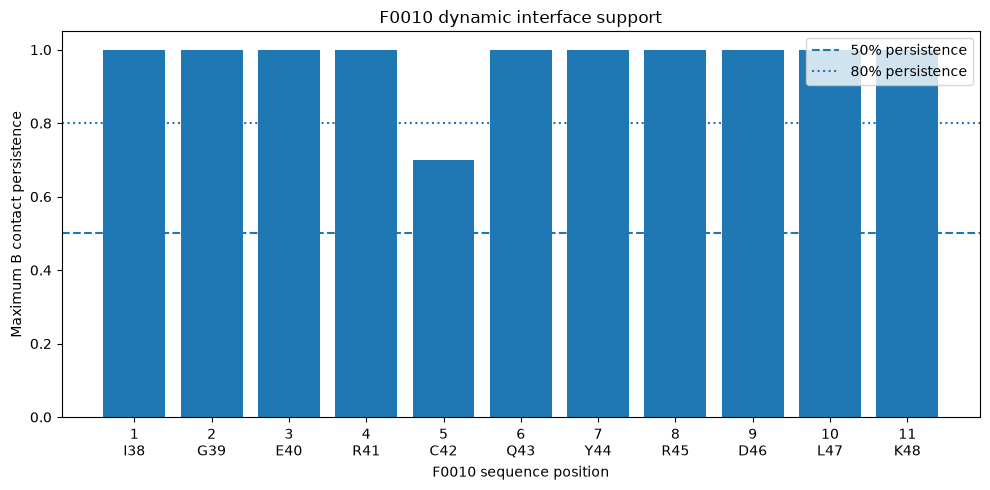

In [23]:
plt.figure(figsize=(10, 5))

plt.bar(
    f0010_dynamic_df["sequence_position_1based"],
    f0010_dynamic_df["max_contact_persistence"],
)

plt.axhline(
    PERSISTENCE_THRESHOLD,
    linestyle="--",
    label="50% persistence",
)

plt.axhline(
    HIGH_PERSISTENCE_THRESHOLD,
    linestyle=":",
    label="80% persistence",
)

plt.xticks(
    f0010_dynamic_df["sequence_position_1based"],
    [
        f"{row.sequence_position_1based}\n{row.aa}{int(row.resid)}"
        for row in f0010_dynamic_df.itertuples()
    ],
)

plt.ylim(0, 1.05)
plt.xlabel("F0010 sequence position")
plt.ylabel("Maximum B contact persistence")
plt.title("F0010 dynamic interface support")
plt.legend()
plt.tight_layout()

plt.savefig(
    REPORT_DIR / "F0010_dynamic_persistence_profile.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()


## 13. F0010 RMSF profile

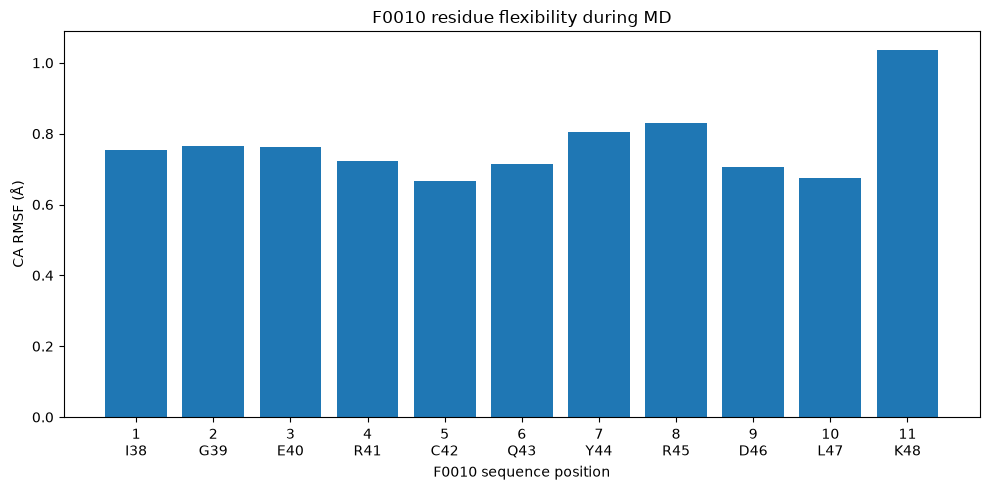

In [24]:
plt.figure(figsize=(10, 5))

plt.bar(
    f0010_dynamic_df["sequence_position_1based"],
    f0010_dynamic_df["CA_RMSF_A"],
)

plt.xticks(
    f0010_dynamic_df["sequence_position_1based"],
    [
        f"{row.sequence_position_1based}\n{row.aa}{int(row.resid)}"
        for row in f0010_dynamic_df.itertuples()
    ],
)

plt.xlabel("F0010 sequence position")
plt.ylabel("CA RMSF (Å)")
plt.title("F0010 residue flexibility during MD")
plt.tight_layout()

plt.savefig(
    REPORT_DIR / "F0010_RMSF_profile.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()


## 14. F0010 contact partners on chain B

In [25]:
f0010_contact_df = contact_df[
    contact_df["D_resid"].between(
        F0010_START_RESID,
        F0010_END_RESID,
    )
].copy()

f0010_contact_df = (
    f0010_contact_df
    .sort_values(
        [
            "D_resid",
            "persistence",
        ],
        ascending=[True, False],
    )
)

f0010_contact_df.to_csv(
    TABLE_DIR / "F0010_chainB_contact_partners.csv",
    index=False,
)

print(
    "Unique chain-B residues contacting F0010:",
    f0010_contact_df["B_resid"].nunique(),
)

print(
    "Persistent F0010 contacts >=50%:",
    (
        f0010_contact_df["persistence"]
        >= PERSISTENCE_THRESHOLD
    ).sum(),
)

display(
    f0010_contact_df.head(50)
)


Unique chain-B residues contacting F0010: 28
Persistent F0010 contacts >=50%: 32


,B_resname,B_resid,D_resname,D_resid,frames_in_contact,n_frames,persistence,persistence_percent,mean_min_distance_A,persistent_50pct
43,LEU,17,ILE,38,438,500,0.876,87.6,3.925744,True
50,HIS,409,ILE,38,423,500,0.846,84.6,3.911460,True
91,SER,11,ILE,38,119,500,0.238,23.8,4.071510,False
100,ASN,12,ILE,38,60,500,0.120,12.0,3.947677,False
7,THR,15,GLY,39,500,500,1.000,100.0,3.381690,True
25,SER,11,GLY,39,493,500,0.986,98.6,3.583823,True
83,ASN,12,GLY,39,184,500,0.368,36.8,3.828623,False
88,LEU,17,GLY,39,133,500,0.266,26.6,4.179118,False
11,THR,15,GLU,40,500,500,1.000,100.0,3.493119,True
28,LYS,13,GLU,40,489,500,0.978,97.8,2.999090,True


## 15. Persistent F0010 contact network table

In [26]:
persistent_f0010_contacts_df = (
    f0010_contact_df[
        f0010_contact_df["persistence"]
        >= PERSISTENCE_THRESHOLD
    ]
    .copy()
)

persistent_f0010_contacts_df.to_csv(
    TABLE_DIR
    / "F0010_persistent_contacts_50pct.csv",
    index=False,
)

display(
    persistent_f0010_contacts_df
)


,B_resname,B_resid,D_resname,D_resid,frames_in_contact,n_frames,persistence,persistence_percent,mean_min_distance_A,persistent_50pct
43,LEU,17,ILE,38,438,500,0.876,87.6,3.925744,True
50,HIS,409,ILE,38,423,500,0.846,84.6,3.911460,True
7,THR,15,GLY,39,500,500,1.000,100.0,3.381690,True
25,SER,11,GLY,39,493,500,0.986,98.6,3.583823,True
11,THR,15,GLU,40,500,500,1.000,100.0,3.493119,True
28,LYS,13,GLU,40,489,500,0.978,97.8,2.999090,True
33,SER,11,GLU,40,482,500,0.964,96.4,3.592324,True
71,ASN,12,GLU,40,330,500,0.660,66.0,4.053390,True
0,ASP,355,ARG,41,500,500,1.000,100.0,2.766057,True
12,PHE,357,ARG,41,500,500,1.000,100.0,3.503473,True


## 16. F0010 contact-persistence heatmap

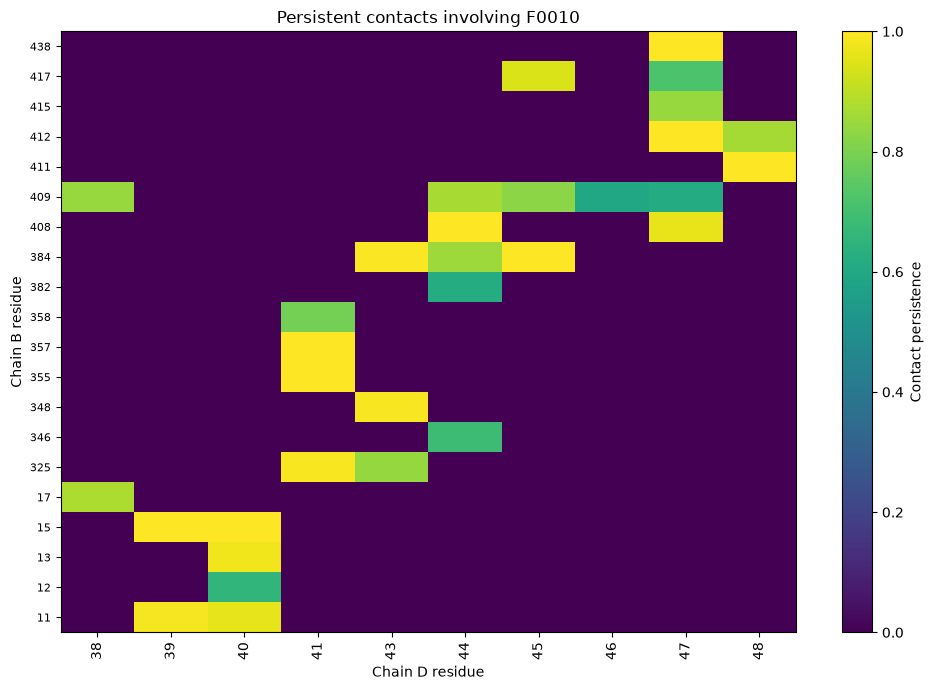

In [27]:
if not persistent_f0010_contacts_df.empty:
    heat = persistent_f0010_contacts_df.pivot_table(
        index="B_resid",
        columns="D_resid",
        values="persistence",
        fill_value=0.0,
        aggfunc="max",
    )

    plt.figure(figsize=(10, 7))
    plt.imshow(
        heat.values,
        aspect="auto",
        origin="lower",
        vmin=0,
        vmax=1,
    )

    plt.colorbar(
        label="Contact persistence"
    )

    plt.xticks(
        range(len(heat.columns)),
        heat.columns,
        rotation=90,
    )

    plt.yticks(
        range(len(heat.index)),
        heat.index,
        fontsize=8,
    )

    plt.xlabel("Chain D residue")
    plt.ylabel("Chain B residue")
    plt.title("Persistent contacts involving F0010")
    plt.tight_layout()

    plt.savefig(
        REPORT_DIR
        / "F0010_persistent_contact_heatmap.png",
        dpi=250,
        bbox_inches="tight",
    )

    plt.show()


## 17. Build a simple multi-evidence residue score

In [28]:
# This score is descriptive, not a physical energy.
# It combines normalized dynamic persistence and FoldX hotspot evidence.

if integrated_df is not None:
    score_df = integrated_df.copy()

    score_df["dynamic_component"] = (
        score_df["max_contact_persistence"]
        .clip(0, 1)
    )

    if score_df["foldx_ddG_kcal_mol"].notna().any():
        ddg = score_df["foldx_ddG_kcal_mol"].copy()

        ddg_min = ddg.min(skipna=True)
        ddg_max = ddg.max(skipna=True)

        if (
            np.isfinite(ddg_min)
            and np.isfinite(ddg_max)
            and ddg_max > ddg_min
        ):
            score_df["foldx_component"] = (
                (ddg - ddg_min)
                / (ddg_max - ddg_min)
            )
        else:
            score_df["foldx_component"] = 0.0
    else:
        score_df["foldx_component"] = 0.0

    score_df["foldx_component"] = (
        score_df["foldx_component"]
        .fillna(0.0)
    )

    score_df["combined_evidence_score"] = (
        0.5 * score_df["dynamic_component"]
        + 0.5 * score_df["foldx_component"]
    )

    score_df.to_csv(
        TABLE_DIR
        / "combined_dynamic_foldx_residue_score.csv",
        index=False,
    )

    display(
        score_df.sort_values(
            "combined_evidence_score",
            ascending=False,
        ).head(30)
    )
else:
    score_df = None
    print(
        "Combined evidence score skipped because FoldX data is unavailable."
    )


,resid,resname,max_contact_persistence,mean_contact_persistence,n_partner_residues,chain,dynamic_contact_support,CA_RMSF_A,foldx_ddG_kcal_mol,is_foldx_hotspot,is_md_persistent,is_md_very_persistent,evidence_class,dynamic_component,foldx_component,combined_evidence_score
67,39,GLY,1.00,0.800000,4,D,very_persistent,0.765753,5.87659,True,True,True,FoldX_hotspot_and_MD_persistent,1.00,1.000000,1.000000
69,41,ARG,1.00,0.840000,5,D,very_persistent,0.721614,5.73455,True,True,True,FoldX_hotspot_and_MD_persistent,1.00,0.965586,0.982793
56,26,LEU,1.00,0.597143,7,D,very_persistent,0.932635,4.15852,True,True,True,FoldX_hotspot_and_MD_persistent,1.00,0.583736,0.791868
65,37,TYR,0.78,0.316000,5,D,persistent,0.799034,4.64586,True,True,False,FoldX_hotspot_and_MD_persistent,0.78,0.701812,0.740906
53,23,ILE,1.00,0.680000,4,D,very_persistent,0.845328,3.65614,True,True,True,FoldX_hotspot_and_MD_persistent,1.00,0.462017,0.731008
75,47,LEU,1.00,0.695556,9,D,very_persistent,0.674007,3.54371,True,True,True,FoldX_hotspot_and_MD_persistent,1.00,0.434777,0.717388
72,44,TYR,1.00,0.705714,7,D,very_persistent,0.805082,3.37068,True,True,True,FoldX_hotspot_and_MD_persistent,1.00,0.392854,0.696427
49,13,TYR,1.00,0.530000,2,D,very_persistent,0.972796,3.32989,True,True,True,FoldX_hotspot_and_MD_persistent,1.00,0.382971,0.691486
62,33,CYS,1.00,0.610000,4,D,very_persistent,0.754004,2.91303,True,True,True,FoldX_hotspot_and_MD_persistent,1.00,0.281972,0.640986
48,12,GLY,1.00,0.733333,3,D,very_persistent,1.212198,2.88259,True,True,True,FoldX_hotspot_and_MD_persistent,1.00,0.274597,0.637298


## 18. Interpretation categories

The notebook uses the following qualitative categories:

```text
FoldX hotspot + high MD persistence
    → strongest cross-method computational support

FoldX hotspot + low MD persistence
    → energetically important in the static model,
      but dynamically less stable in this trajectory

non-hotspot + high MD persistence
    → structural contact maintained dynamically,
      but not strongly energetic by FoldX alanine scanning

low FoldX + low persistence
    → weakest current interface support
```

This categorisation is deliberately conservative and descriptive.


## 19. Automatic summary

In [29]:
n_f0010_md_persistent = int(
    f0010_dynamic_df["is_md_persistent"]
    .sum()
)

n_f0010_positions = len(
    f0010_dynamic_df
)

f0010_persistent_fraction = (
    n_f0010_md_persistent
    / n_f0010_positions
)

n_f0010_contacts_persistent = len(
    persistent_f0010_contacts_df
)

if hotspot_df is not None:
    n_f0010_foldx_hotspots = int(
        f0010_dynamic_df["is_foldx_hotspot"]
        .fillna(False)
        .sum()
    )

    n_f0010_dual = int(
        (
            f0010_dynamic_df["is_md_persistent"]
            & f0010_dynamic_df["is_foldx_hotspot"].fillna(False)
        ).sum()
    )
else:
    n_f0010_foldx_hotspots = None
    n_f0010_dual = None

summary = {
    "run_source": RUN_LABEL,
    "F0010_sequence": F0010_SEQUENCE,
    "F0010_chain": CHAIN_D,
    "F0010_residue_interval": f"{F0010_START_RESID}-{F0010_END_RESID}",
    "n_F0010_positions": n_f0010_positions,
    "n_F0010_MD_persistent_positions": n_f0010_md_persistent,
    "F0010_MD_persistent_fraction": f0010_persistent_fraction,
    "n_F0010_persistent_contacts": n_f0010_contacts_persistent,
    "n_F0010_FoldX_hotspots": n_f0010_foldx_hotspots,
    "n_F0010_dual_FoldX_MD_support": n_f0010_dual,
    "foldx_file_used": str(HOTSPOT_FILE) if HOTSPOT_FILE else None,
}

summary_df = pd.DataFrame([summary])

summary_df.to_csv(
    TABLE_DIR / "07c_summary_metrics.csv",
    index=False,
)

display(summary_df.T)


,0
run_source,production_1ns
F0010_sequence,IGERCQYRDLK
F0010_chain,D
F0010_residue_interval,38-48
n_F0010_positions,11
n_F0010_MD_persistent_positions,11
F0010_MD_persistent_fraction,1.0
n_F0010_persistent_contacts,32
n_F0010_FoldX_hotspots,6
n_F0010_dual_FoldX_MD_support,6


## 20. Generate final report

In [30]:
if hotspot_df is not None:
    dual_support_rows = f0010_dynamic_df[
        f0010_dynamic_df["is_md_persistent"]
        & f0010_dynamic_df["is_foldx_hotspot"].fillna(False)
    ]

    dual_text = "\n".join([
        (
            f"- D:{row.aa}{int(row.resid)} "
            f"(position {int(row.sequence_position_1based)}): "
            f"MD persistence={row.max_contact_persistence:.2f}, "
            f"FoldX ddG={row.foldx_ddG_kcal_mol:.3f} kcal/mol"
        )
        for row in dual_support_rows.itertuples()
    ])

    if not dual_text:
        dual_text = "- none"
else:
    dual_text = "- FoldX hotspot file not available"

top_f0010_contacts_text = "\n".join([
    (
        f"- B:{row.B_resname}{int(row.B_resid)} "
        f"- D:{row.D_resname}{int(row.D_resid)}: "
        f"{row.persistence_percent:.1f}%"
    )
    for row in persistent_f0010_contacts_df.head(15).itertuples()
])

if not top_f0010_contacts_text:
    top_f0010_contacts_text = "- none"

report = f"""# 07c - EGFR MD Hotspot and Interface Validation

## Source
- MD run: {RUN_LABEL}
- F0010: {F0010_SEQUENCE}
- F0010 chain-D interval: {F0010_START_RESID}-{F0010_END_RESID}
- MD persistent-contact threshold: {PERSISTENCE_THRESHOLD:.0%}
- FoldX hotspot threshold: {FOLDX_HOTSPOT_THRESHOLD:.1f} kcal/mol

## F0010 dynamic support
- Positions analysed: {n_f0010_positions}
- MD-persistent positions: {n_f0010_md_persistent}
- MD-persistent fraction: {f0010_persistent_fraction:.3f}
- Persistent B-F0010 residue contacts: {n_f0010_contacts_persistent}

## FoldX integration
- Hotspot file: {HOTSPOT_FILE}
- F0010 FoldX hotspots: {n_f0010_foldx_hotspots}
- F0010 positions supported by both FoldX and MD: {n_f0010_dual}

## F0010 residues with dual FoldX/MD support
{dual_text}

## Top persistent F0010 contacts
{top_f0010_contacts_text}

## Interpretation
This notebook integrates static energetic hotspot evidence with dynamic
contact persistence from the 1 ns EGFR B-D molecular-dynamics trajectory.

Residues supported by both FoldX and MD receive stronger computational
support than residues supported by only one method. This remains a
computational prioritization and does not constitute experimental
validation of binding or inhibition.
"""

REPORT_PATH = (
    REPORT_DIR
    / "07c_MD_hotspot_interface_validation_report.md"
)

REPORT_PATH.write_text(
    report,
    encoding="utf-8",
)

print(report)
print("Report:", REPORT_PATH.resolve())


# 07c - EGFR MD Hotspot and Interface Validation

## Source
- MD run: production_1ns
- F0010: IGERCQYRDLK
- F0010 chain-D interval: 38-48
- MD persistent-contact threshold: 50%
- FoldX hotspot threshold: 1.5 kcal/mol

## F0010 dynamic support
- Positions analysed: 11
- MD-persistent positions: 11
- MD-persistent fraction: 1.000
- Persistent B-F0010 residue contacts: 32

## FoldX integration
- Hotspot file: outputs/energetic_hotspots.csv
- F0010 FoldX hotspots: 6
- F0010 positions supported by both FoldX and MD: 6

## F0010 residues with dual FoldX/MD support
- D:G39 (position 2): MD persistence=1.00, FoldX ddG=5.877 kcal/mol
- D:R41 (position 4): MD persistence=1.00, FoldX ddG=5.735 kcal/mol
- D:Q43 (position 6): MD persistence=1.00, FoldX ddG=2.516 kcal/mol
- D:Y44 (position 7): MD persistence=1.00, FoldX ddG=3.371 kcal/mol
- D:R45 (position 8): MD persistence=1.00, FoldX ddG=2.003 kcal/mol
- D:L47 (position 10): MD persistence=1.00, FoldX ddG=3.544 kcal/mol

## Top persistent F0010 c

# 21. How to interpret the result

The most important outputs are:

```text
tables/
├── dynamic_interface_residue_support.csv
├── dynamic_interface_with_rmsf.csv
├── FoldX_MD_integrated_residue_validation.csv
├── F0010_MD_dynamic_support.csv
├── F0010_chainB_contact_partners.csv
├── F0010_persistent_contacts_50pct.csv
├── combined_dynamic_foldx_residue_score.csv
└── 07c_summary_metrics.csv
```

and:

```text
reports/
├── F0010_dynamic_persistence_profile.png
├── F0010_RMSF_profile.png
├── F0010_persistent_contact_heatmap.png
└── 07c_MD_hotspot_interface_validation_report.md
```

---

## Scientific next step

After this notebook there are two possible directions:

### A. Extend the dimer MD

If the 1 ns trajectory is still evolving strongly, extend the same B–D simulation to 5–10 ns before making stronger claims.

### B. Move to selected peptide complexes

If the B–D interface is sufficiently stable and the dynamically supported hotspot region is clear, use the next notebook to compare:

```text
F0010
CF_06
CF_02
```

in bound-state MD.

This would directly test whether the optimized peptides preserve the same key dynamic interface contacts as the natural F0010 reference.
